In [1]:
import os
import json
a = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/raw/train_concat/data.list'
with open(a, 'r', encoding='utf-8') as reader, \
    open(os.path.join(os.path.dirname(a), 'text'), 'w', encoding='utf-8') as writer_text, \
    open(os.path.join(os.path.dirname(a), 'wav.scp'), 'w', encoding='utf-8') as writer_wav:
    line = reader.readline()
    while(line):
        line = json.loads(line.strip())
        key = line['key']
        wav = line['wav']
        txt = line['txt']
        writer_text.write(txt + '\n')
        writer_wav.write(' '.join([key, wav]) + '\n')
        line = reader.readline()

In [13]:
import os
import json, yaml
from local.me.utils.computer_wer_per_epoch import compute_wer

from local.me.text.bpe_tokenizer import BpeTokenizer

def init_tokenizer(bpe_path, symbol_table_path):
    tokenizer = BpeTokenizer(bpe_path,
                            symbol_table_path,
                            None,
                            False)
    return tokenizer

def get_drwer_file(original_path, tokenizer: BpeTokenizer):
    with open(original_path, 'r', encoding='utf-8') as reader:
        lines = reader.readlines()
    info = os.path.basename(original_path).split('.')
    lines_temp = []
    for line in lines:
        lines_temp.append(json.loads(line.strip()))
    lines = sorted(lines_temp, key=lambda x: x['key'])
    with open(os.path.join(os.path.dirname(original_path), info[0] + '_nodel.' + info[1]), 'w', encoding='utf-8') as writer:
        for line in lines:
            txt = line['text']
            key = line['key']
            txt = tokenizer.detokenize(txt)[0].strip().split()
            writer.write(' '.join([key, ' '.join(txt)]) + '\n')

# compare = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/compare.txt'
# with open('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/comparecopy.txt', 'r', encoding='utf-8') as reader:
#     lines = reader.readlines()
# print(lines[:10])
# line_temp = []
# for line in lines:
#     line_temp.append(line.strip().split(' ', maxsplit=1))
# lines = sorted(line_temp, key=lambda x: x[0])
# with open('temp/compare.txt', 'w', encoding='utf-8') as writer:
#     for line in lines:
#         writer.write(' '.join(line) + '\n')

# compare = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/raw/test/data.list'
# with open(compare, 'r', encoding='utf-8') as reader:
#     lines = reader.readlines()
# with open('temp/compare.txt', 'w', encoding='utf-8') as writer:
#     for line in lines:
#         line = json.loads(line.strip())
#         key = line['key']
#         txt = line['txt']
#         writer.write(' '.join([key.strip(), txt.strip()]) + '\n')


swbd_tokenizer = init_tokenizer('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/data/swbd_lang_char/swbd_bpe2000.model',
                    '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/data/swbd_lang_char/swbd_bpe2000_units.txt')
concat_tokenizer = init_tokenizer('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/data/concat_lang_char/concat_bpe2000.model',
                    '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/data/concat_lang_char/concat_bpe2000_units.txt')
file_path_base = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp'
file_paths = [i for i in os.listdir(file_path_base) if os.path.isdir(os.path.join(file_path_base, i))]
for file_path in file_paths:
    if 'swbd' in file_path:
        tokenizer = swbd_tokenizer
    else:
        tokenizer = concat_tokenizer
    file_path_base_next = os.path.join(file_path_base, file_path)
    filepaths = [i for i in os.listdir(file_path_base_next) if 'original' in i and 'nodel' not in i and 'compare' not in i]
    for fpl in filepaths:
        index = fpl.split('_')[1]
        conf_path = os.path.join('exp', file_path, f'epoch_{index}.yaml')
        with open(conf_path, 'r') as file:
            info = yaml.safe_load(file)
        if 'dr_wer' in info:
            pass
        else:
            print(conf_path)
            finalpath = os.path.join(file_path_base_next, fpl)
            get_drwer_file(finalpath, tokenizer)
            this_info = fpl.split('.')
            to_path = os.path.join(file_path_base_next, this_info[0] + '_nodel.' + this_info[1])
            wer_info = compute_wer('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/compare.txt', to_path)
            info['dr_wer'] = info['wer']
            info['wer'] = wer_info
            with open(conf_path, 'w') as fout:
                data = yaml.dump(info)
                fout.write(data)
        


exp/mebpe_concatf_concat_new2_sig_or_cross_focal/epoch_43.yaml
exp/mebpe_concatf_swbd_asr_only/epoch_62.yaml


In [5]:
import os, json
path = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/raw/concat/data.list'
all = 0
one = 0
with open(path, 'r', encoding='utf-8') as reader:
    line = reader.readline()
    while(line):
        line = json.loads(line.strip())
        label = line['dysfl_label'].strip().split(' ')
        all += len(label)
        one += label.count('1')
        line = reader.readline()
print(one/all)

0.07854378541605035


In [11]:
import os, json

path = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/raw/test/data.list'
b = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/compare.txt'
with open(path, 'r', encoding='utf-8') as reader:
    lines = reader.readlines()
lines_temp = {}
for line in lines:
    line = json.loads(line.strip())
    lines_temp[line['key']] = line['dysfl_label']
with open(b, 'r', encoding='utf-8') as reader, \
    open('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/compare_del.txt', 'w', encoding='utf-8') as writer:
    line = reader.readline()
    while(line):
        info = line.strip().split(' ')
        key = info[0]
        txt = info[1:]
        dysfl = lines_temp[key].strip().split()
        assert len(txt) == len(dysfl)
        txt_new = []
        for index, dysf in enumerate(dysfl):
            if dysf == '0':
                txt_new.append(txt[index])
        new_text = ' '.join(txt_new)
        write_line = f'{key} {new_text}\n'
        writer.write(write_line)
        line = reader.readline()

In [ ]:
import os
import json, yaml
from local.me.utils.computer_wer_per_epoch import compute_wer

from local.me.text.bpe_tokenizer import BpeTokenizer

def init_tokenizer(bpe_path, symbol_table_path):
    tokenizer = BpeTokenizer(bpe_path,
                            symbol_table_path,
                            None,
                            False)
    return tokenizer

def get_drwer_file(original_path, tokenizer: BpeTokenizer):
    with open(original_path, 'r', encoding='utf-8') as reader:
        lines = reader.readlines()
    info = os.path.basename(original_path).split('.')
    lines_temp = []
    for line in lines:
        lines_temp.append(json.loads(line.strip()))
    lines = sorted(lines_temp, key=lambda x: x['key'])
    with open(os.path.join(os.path.dirname(original_path), info[0] + '_nodel.' + info[1]), 'w', encoding='utf-8') as writer:
        for line in lines:
            txt = line['text']
            key = line['key']
            txt = tokenizer.detokenize(txt)[0].strip().split()
            writer.write(' '.join([key, ' '.join(txt)]) + '\n')

# compare = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/compare.txt'
# with open('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/comparecopy.txt', 'r', encoding='utf-8') as reader:
#     lines = reader.readlines()
# print(lines[:10])
# line_temp = []
# for line in lines:
#     line_temp.append(line.strip().split(' ', maxsplit=1))
# lines = sorted(line_temp, key=lambda x: x[0])
# with open('temp/compare.txt', 'w', encoding='utf-8') as writer:
#     for line in lines:
#         writer.write(' '.join(line) + '\n')

# compare = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/raw/test/data.list'
# with open(compare, 'r', encoding='utf-8') as reader:
#     lines = reader.readlines()
# with open('temp/compare.txt', 'w', encoding='utf-8') as writer:
#     for line in lines:
#         line = json.loads(line.strip())
#         key = line['key']
#         txt = line['txt']
#         writer.write(' '.join([key.strip(), txt.strip()]) + '\n')


swbd_tokenizer = init_tokenizer('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/data/swbd_lang_char/swbd_bpe2000.model',
                    '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/data/swbd_lang_char/swbd_bpe2000_units.txt')
concat_tokenizer = init_tokenizer('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/data/concat_lang_char/concat_bpe2000.model',
                    '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/data/concat_lang_char/concat_bpe2000_units.txt')
file_path_base = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp'
file_paths = [i for i in os.listdir(file_path_base) if os.path.isdir(os.path.join(file_path_base, i))]
for file_path in file_paths:
    if 'swbd' in file_path:
        tokenizer = swbd_tokenizer
    else:
        tokenizer = concat_tokenizer
    file_path_base_next = os.path.join(file_path_base, file_path)
    filepaths = [i for i in os.listdir(file_path_base_next) if 'original' in i and 'nodel' not in i and 'compare' not in i]
    for fpl in filepaths:
        index = fpl.split('_')[1]
        conf_path = os.path.join('exp', file_path, f'epoch_{index}.yaml')
        if not os.path.exists(conf_path):
            continue
        with open(conf_path, 'r') as file:
            info = yaml.safe_load(file)
        if 'dr_wer' in info:
            pass
        else:
            print(conf_path)
            finalpath = os.path.join(file_path_base_next, fpl)
            get_drwer_file(finalpath, tokenizer)
            this_info = fpl.split('.')
            to_path = os.path.join(file_path_base_next, this_info[0] + '_nodel.' + this_info[1])
            if 'asr_only' not in file_path:
                wer_info = compute_wer('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/compare.txt', to_path)
                info['dr_wer'] = info['wer']
                info['wer'] = wer_info
            else:
                wer_info = compute_wer('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/compare.txt', to_path)
                info['wer'] = wer_info
                wer_info = compute_wer('/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/compare_del.txt', to_path)
                info['dr_wer'] = wer_info
            with open(conf_path, 'w') as fout:
                data = yaml.dump(info)
                fout.write(data)

KeyboardInterrupt: 

93 epochs
Save pic to /s6home/gw522/projects/ASR/wenet-240322/examples/swbd/joint/pic/joint/split/cv.jpg
88 epochs
Save pic to /s6home/gw522/projects/ASR/wenet-240322/examples/swbd/joint/pic/joint/split1/cv.jpg


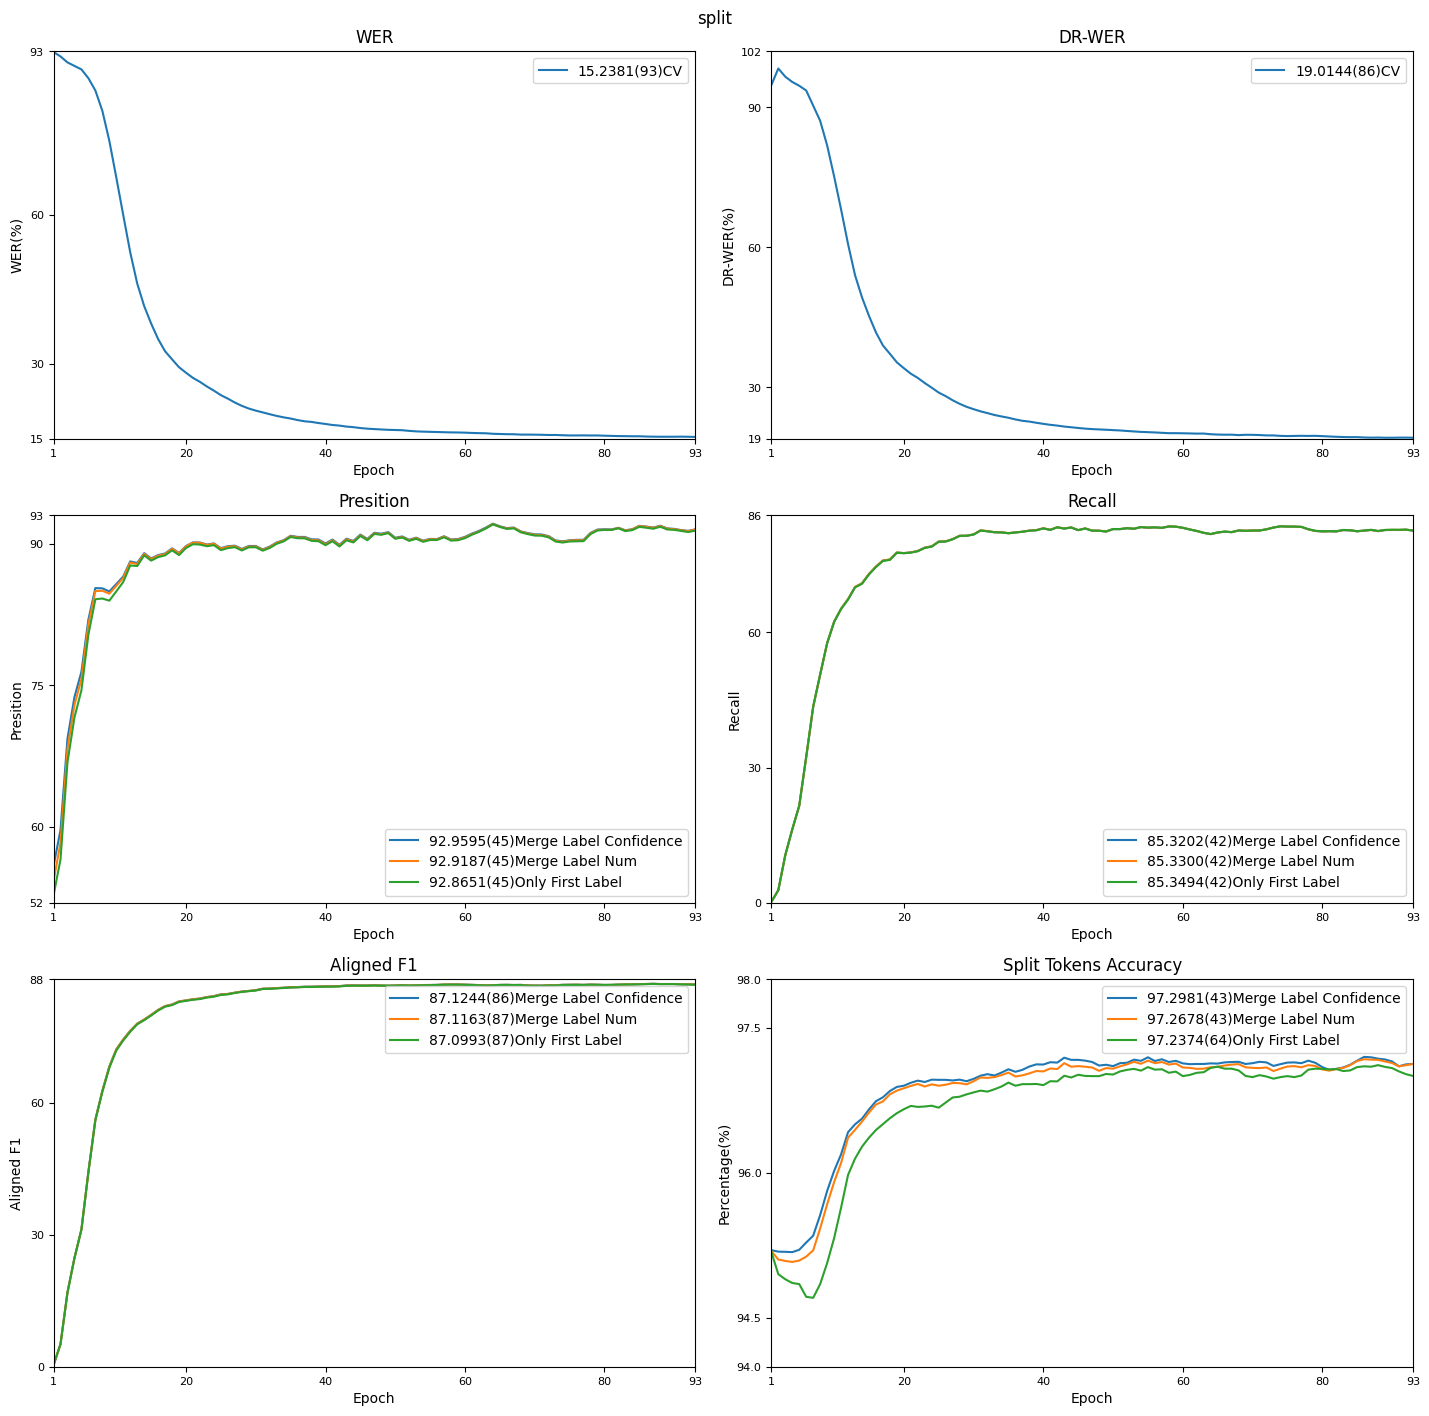

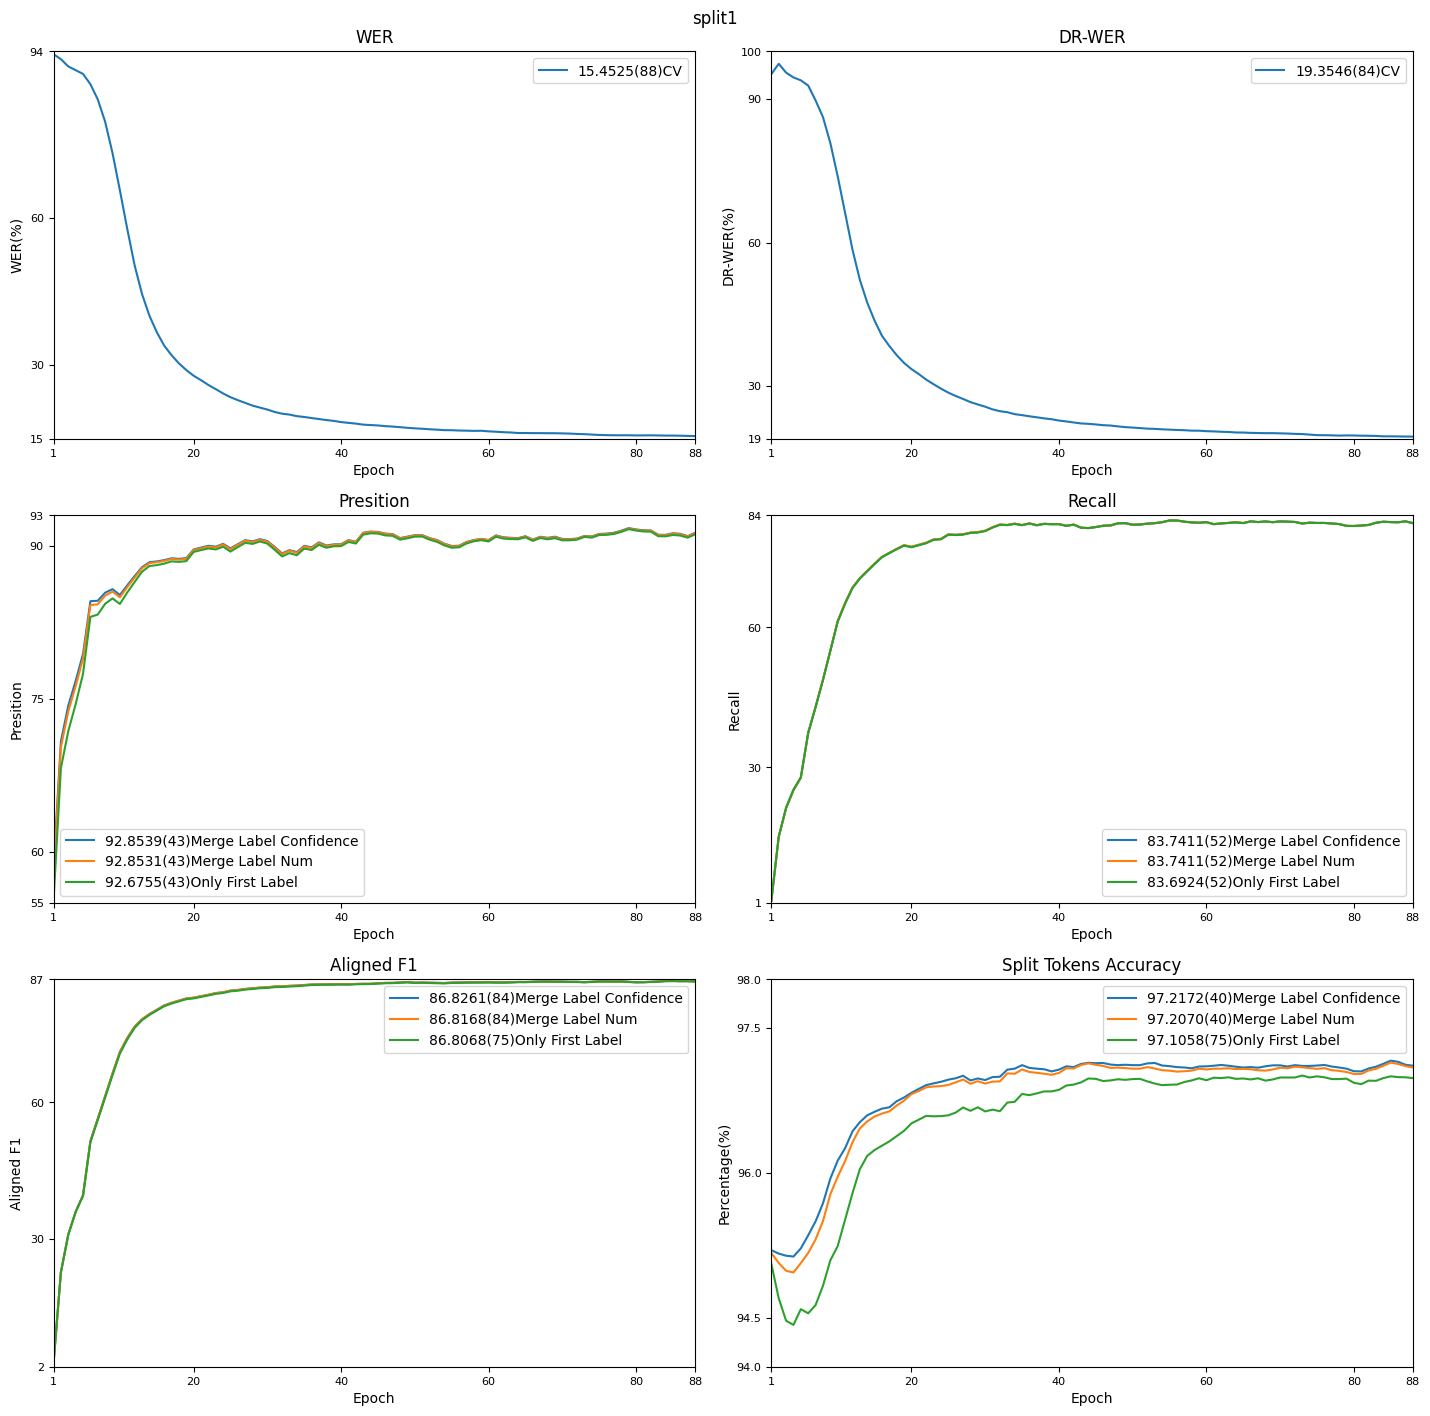

In [2]:
from myself_tools.draw_picture import draw_sub_pic, Sub_pic_info
import yaml
import os, copy

def draw(floader):
    log_path = floader
    assert os.path.exists(log_path)
    pic_path = os.path.join('./pic/joint', os.path.basename(floader))
    # train_pic_name = os.path.join(pic_path, 'train.jpg')
    cv_pic_name = os.path.join(pic_path, 'cv.jpg')
    loss_arr = [[], []]
    p_arr = [[[], []], [[], [], []]]
    r_arr = [[[], []], [[], [], []]]
    f_arr = [[[], []], [[], [], []]]
    lr_arr = []
    wer_arr = []
    dr_wer_arr = []
    split_correct = []
    merge_split_correct = []
    merge_score_split_correct = []
    start = 0
    end_flag = False
    while(not end_flag):
        # if start + 1 >= 80:
        #     end_flag = True
        yaml_file_path = os.path.join(log_path, f'epoch_{start}.yaml')
        if os.path.exists(yaml_file_path):
            with open(yaml_file_path, 'r') as file:
                info = yaml.safe_load(file)
            lr_arr.append(info['lr'] * 10**5)
            # eval_info = info['train_loss_dict']
            # p_arr[0][0].append(eval_info['info']['p_score'])
            # r_arr[0][0].append(eval_info['info']['r_score'])
            # f_arr[0][0].append(eval_info['info']['f_score'])
            # p_arr[0][1].append(eval_info['info_merge']['p_score'])
            # r_arr[0][1].append(eval_info['info_merge']['r_score'])
            # f_arr[0][1].append(eval_info['info_merge']['f_score'])
            # loss_arr[0].append(eval_info['loss'])
            eval_info = info['loss_dict']
            if 'asr_only' not in floader:
                merge_score_split_correct.append(eval_info.get('merge_score_split_correct', 0))
                merge_split_correct.append(eval_info.get('merge_split_correct', 0))
                split_correct.append(eval_info.get('split_correct', 0))
                p_arr[1][0].append(eval_info.get('merge_score_p_score', 0))
                r_arr[1][0].append(eval_info.get('merge_score_r_score', 0))
                f_arr[1][0].append(eval_info.get('merge_score_f_score', 0))
                p_arr[1][1].append(eval_info['merge_p_score'])
                r_arr[1][1].append(eval_info['merge_r_score'])
                f_arr[1][1].append(eval_info['merge_f_score'])
                p_arr[1][2].append(eval_info['p_score'])
                r_arr[1][2].append(eval_info['r_score'])
                f_arr[1][2].append(eval_info['f_score'])
            if 'dr_wer' not in info:
                print(yaml_file_path)
            dr_wer_arr.append(info['dr_wer']["Overall"]['wer'])
            wer_arr.append(info['wer']["Overall"]['wer'])
            loss_arr[1].append(info['loss_dict']['loss'])
            start += 1
        else:
            break

    epoch_num = len(lr_arr)
    print(f'{epoch_num} epochs')
    if epoch_num > 2:
        os.makedirs(pic_path, exist_ok=True)
        # object_arr = []
        # object_arr.append(Sub_pic_info('lr', 'epoch', 'lr', [i + 1 for i in range(epoch_num)], lr_arr, 'lr(10**5)'))
        # object_arr.append(Sub_pic_info('train_loss', 'epoch', 'loss', [i + 1 for i in range(epoch_num)], loss_arr[0], 'train'))
        # object_arr.append(Sub_pic_info('train_f1_score', 'epoch', 'score', [[i + 1 for i in range(epoch_num)]] * 2, f_arr[0], ['none', 'merge']))
        # object_arr.append(Sub_pic_info('train_p_score', 'epoch', 'score', [[i + 1 for i in range(epoch_num)]] * 2, p_arr[0], ['none', 'merge']))
        # object_arr.append(Sub_pic_info('train_r_score', 'epoch', 'score', [[i + 1 for i in range(epoch_num)]] * 2, r_arr[0], ['none', 'merge']))
        # draw_sub_pic(object_arr, train_pic_name, 2, 3)
        object_arr1 = []
        object_arr1.append(Sub_pic_info('WER', 'Epoch', 'WER(%)', [i + 1 for i in range(epoch_num)], wer_arr, 'CV', 0))
        object_arr1.append(Sub_pic_info('DR-WER', 'Epoch', 'DR-WER(%)', [i + 1 for i in range(epoch_num)], dr_wer_arr,'CV', 0))
        if 'asr_only' not in floader:
            object_arr1.append(Sub_pic_info('Presition', 'Epoch', 'Presition', [[i + 1 for i in range(epoch_num)]] * 3, p_arr[1], ['Merge Label Confidence', 'Merge Label Num', 'Only First Label'], [1]*3))
            object_arr1.append(Sub_pic_info('Recall', 'Epoch', 'Recall', [[i + 1 for i in range(epoch_num)]] * 3, r_arr[1],  ['Merge Label Confidence', 'Merge Label Num', 'Only First Label'], [1]*3))
            object_arr1.append(Sub_pic_info('Aligned F1', 'Epoch', 'Aligned F1', [[i + 1 for i in range(epoch_num)]] * 3, f_arr[1], ['Merge Label Confidence', 'Merge Label Num', 'Only First Label'], [1]*3))
            object_arr1.append(Sub_pic_info('Split Tokens Accuracy', 'Epoch', 'Percentage(%)', [[i + 1 for i in range(epoch_num)]] * 3, [merge_score_split_correct, merge_split_correct, split_correct ], ['Merge Label Confidence', 'Merge Label Num', 'Only First Label'], [1]*3))
            # object_arr1.append(Sub_pic_info('Loss', 'Epoch', 'Loss', [i + 1 for i in range(epoch_num)], loss_arr[1], 'CV'))
            draw_sub_pic(object_arr1, cv_pic_name, 3, 2, ' '.join(os.path.basename(floader).strip().split('_')), True)
        else:
            # object_arr1.append(Sub_pic_info('Loss', 'Epoch', 'Loss', [i + 1 for i in range(epoch_num)], loss_arr[1], 'CV'))
            draw_sub_pic(object_arr1, cv_pic_name, 1, 2, ' '.join(os.path.basename(floader).strip().split('_')), True)
        return [wer_arr, dr_wer_arr, f_arr[1][0]]

floader = './exp'
floaders = ['mebpe_concatf_concat_new2_sig_or_cross', 'mebpe_concatf_concat_new2_sig_or_cross_focal', 'mebpe_concatf_swbd_new2_sig_or_cross', 'mebpe_concatf_concat_new2_sig_or_cross_no_extra', 'mebpe_concatf_swbd_new2_sig_or_cross_no_extra', 'mebpe_concatf_swbd_asr_only']
reflex = ['joint+expand+psd', 'joint+expand+psd+focal', 'joint+psd', 'joint+expand', 'joint', 'only_asr']
floaders = ['split', 'split1']
reflex = ['joint+expand+psd+focal'] * 2
floaders = [os.path.join(floader, x) for x in floaders]
all_objs = []
show_objs = [[], [], []]
show_objs_next = []
for floader in floaders:
    all_objs.append(draw(floader))
# for index, this_type in enumerate(all_objs):
#     for index1 , h in enumerate(this_type):
#         show_objs[index1].append(h)
# for index, this_type in enumerate(show_objs):
#     type_temp = copy.copy(reflex)
#     if index == 0:
#         show_objs_next.append(Sub_pic_info('WER', 'Epoch', 'WER(%)', [list(range(1, len(i)+1)) for i in this_type], this_type, type_temp, [0]*len(type_temp)))
#     elif index == 1:
#         show_objs_next.append(Sub_pic_info('DR-WER', 'Epoch', 'DR-WER(%)', [list(range(1, len(i)+1)) for i in this_type], this_type, type_temp, [0]*len(type_temp)))
#     elif index == 2:
#         for index1, t in enumerate(this_type):
#             if t == []:
#                 type_temp.remove(reflex[index1])
#         this_type = [i for i in this_type if i != []]
#         show_objs_next.append(Sub_pic_info('Aligned F1', 'Epoch', 'Aligned F1', [list(range(1, len(i)+1)) for i in this_type], this_type, type_temp, [1]*len(type_temp)))
# draw_sub_pic(show_objs_next, './pic/total_preview.jpg', 1, 3, 'total_preview', True)


In [25]:
import os, json
compare = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/compare.txt'
a = '/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/temp/mebpe_concatf_concat_new2_sig_or_cross/result_20_original.txt'
with open(a, 'r', encoding='utf-8') as reader:
    lines = reader.readlines()
dict_temp = {}
for line in lines:
    line = json.loads(line.strip())
    key = line['key']
    try:
        t = dict_temp[key]
    except:
        dict_temp[key] = 0
with open(compare, 'r', encoding='utf-8') as reader:
    lines = reader.readlines()
with open(compare, 'w', encoding='utf-8') as reader:
    for line in lines:
        line_temp = line.strip().split(' ', maxsplit=1)
        try:
            t = dict_temp[line_temp[0]]
        except:
            continue
        reader.write(line)


In [2]:
import os, yaml

type_temps = ['mebpe_concatf_concat_new2_sig_or_cross_no_extra']
for type_temp in type_temps:
    log_dir = f'/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/log/{type_temp}/{type_temp}_1.log'
    exp_dir = f'/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/exp/{type_temp}'
    yaml_files = []
    for i in range(80):
        yaml_files.append(os.path.join(exp_dir, f'epoch_{i}.yaml'))
    index = 0
    with open(log_dir, 'r', encoding='utf-8') as reader, \
        open(log_dir + 'g', 'w', encoding='utf-8') as writer:
        line = reader.readline()
        while(line):
            if ' INFO N ' in line:
                time = line.split(' ')[:2]
                time = ' '.join(time)
                with open(yaml_files[index], 'r') as file:
                    info = yaml.safe_load(file)
                wer_info = info['wer']['Overall']
                write_line = ' '.join([time, 'INFO', 'N', str(wer_info['N']), 'C', str(wer_info['C']), 'S', str(wer_info['S']), 'D', str(wer_info['D']), 'I', str(wer_info['I']), 'WER', str(wer_info['wer'])]) + '\n'
                writer.write(write_line)
                wer_info = info['dr_wer']['Overall']
                write_line = ' '.join([time, 'INFO', 'N', str(wer_info['N']), 'C', str(wer_info['C']), 'S', str(wer_info['S']), 'D', str(wer_info['D']), 'I', str(wer_info['I']), 'DR-WER', str(wer_info['wer'])]) + '\n'
                writer.write(write_line)
                index += 1
            else:
                writer.write(line)
            line = reader.readline()
    os.remove(log_dir)
    os.rename(log_dir + 'g', log_dir)

In [18]:
import torch
a = torch.tensor([ 0.1968, -0.4286])
b = torch.softmax(a, dim=-1)
print(b)
print(-torch.log(b[0]))

tensor([0.6514, 0.3486])
tensor(0.4286)


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
a = torch.tensor([ 0.1968, -0.4286])
c = torch.tensor([0, 1], dtype=torch.float32)
b = F.binary_cross_entropy_with_logits(a, c, reduce='none')
print(b)

tensor(0.8633)


/home/gw522/softwares/Miniconda3/envs/cwenet/lib/python3.8/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  warnings.warn(warning.format(ret))


In [6]:
import os, shutil

floaders = ['mebpe_concatf_concat_new2_sig_or_cross', 'mebpe_concatf_concat_new2_sig_or_cross_focal', 'mebpe_concatf_swbd_new2_sig_or_cross', 'mebpe_concatf_concat_new2_sig_or_cross_no_extra', 'mebpe_concatf_swbd_new2_sig_or_cross_no_extra', 'mebpe_concatf_swbd_asr_only']
floaders_or = [os.path.join('exp', i) for i in floaders]
for index, floader in enumerate(floaders_or):
    to_path = os.path.join('result', floaders[index])
    os.makedirs(to_path)
    yamls = [i for i in os.listdir(floader) if i.endswith('yaml') and i.startswith('epoch_')]
    for yaml in yamls:
        shutil.copy(os.path.join(floader, yaml), os.path.join(to_path, yaml))

In [1]:
import json
import wave

def get_wav_duration(file_path):
    with wave.open(file_path, 'rb') as wav_file:
        # 获取帧速率（采样率）
        frame_rate = wav_file.getframerate()
        # 获取总帧数
        num_frames = wav_file.getnframes()
        # 计算持续时间
        duration = num_frames / float(frame_rate)
    return duration

path = "/home/gw522/projects/ASR/wenet-240322/examples/swbd/or/raw/swbd/data.list"
with open(path, 'r', encoding='utf-8') as reader:
    line = reader.readline()
    duration = 0
    while(line):
        line = json.loads(line.strip())
        duration += get_wav_duration(line['wav'])
        line = reader.readline()
print(duration/3600)

119.1373210763873


In [ ]:
import wave
import json
import ast
from pathlib import Path
import soundfile as sf

def calculate_total_audio_hours(manifest_path):
    total_seconds = 0.0
    error_count = 0
    
    with open(manifest_path, 'r', encoding='utf-8') as f:
        for line_number, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
                
            # 1. 解析字典（兼容标准 JSON 和 Python 单引号字典）
            try:
                data = json.loads(line)
            except json.JSONDecodeError:
                try:
                    data = ast.literal_eval(line)
                except Exception as e:
                    print(f"解析错误 (第 {line_number} 行): {e}")
                    error_count += 1
                    continue
            
            # 2. 获取 wav 路径
            wav_path = data.get('wav')
            if not wav_path:
                print(f"警告: 第 {line_number} 行未找到 'wav' 键。")
                continue
            if wav_path.endswith('.wav'):
                # 3. 读取音频头部计算时长
                try:
                    with wave.open(wav_path, 'r') as wav_file:
                        frames = wav_file.getnframes()
                        rate = wav_file.getframerate()
                        duration = frames / float(rate)
                        total_seconds += duration
                except Exception as e:
                    print(f"读取音频失败 [{wav_path}]: {e}")
                    error_count += 1
            elif wav_path.endswith('.flac'):
                try:
                    # sf.info() 只读取文件头信息，速度非常快
                    audio_info = sf.info(wav_path)
                    duration = audio_info.frames / float(audio_info.samplerate)
                    total_seconds += duration
                except Exception as e:
                    print(f"读取音频失败 [{wav_path}]: {e}")
                    error_count += 1

    # 4. 转换为小时
    total_hours = total_seconds / 3600.0
    
    return total_hours, error_count

# ==========================================
# 使用示例：将 'your_dataset.txt' 替换为你的文件路径
# ==========================================
if __name__ == "__main__":
    file_path = ['../data_generate/raw/librispeech/60_screen_librispeech_100_data.list', '../data_generate/raw/librispeech/60_screen_librispeech_360_data.list'] 
    # file_path = ['./raw/swbd/data.list']  
    
    t = 0
    e = 0
    for path in file_path:
        # 确保文件存在再运行
        if Path(path).exists():
            total_hours, error_count = calculate_total_audio_hours(path)
            t += total_hours
            e += error_count
        else:
            print(f"找不到文件: {file_path}")

    print("-" * 30)
    print(f"统计完成！")
    print(f"总时长: {t:.2f} 小时")
    print(f"失败文件数: {e}")
    print("-" * 30)

# 统计完成！
# 总时长: 119.14 小时
# 失败文件数: 0

------------------------------
统计完成！
总时长: 53.40 小时
失败文件数: 0
------------------------------
------------------------------
统计完成！
总时长: 192.93 小时
失败文件数: 0
------------------------------
------------------------------
统计完成！
总时长: 246.33 小时
失败文件数: 0
------------------------------
